<a href="https://colab.research.google.com/github/sri-vyshnavi-jakkam/Project1/blob/main/DR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

In [ ]:
dataset_path = "/content/drive/MyDrive/Retinopathy"

In [ ]:
print(os.listdir(dataset_path))

['export.pkl', 'train.csv', 'Proliferate_DR', 'Severe', 'No_DR', 'Moderate', 'Mild']


In [ ]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=True
)

Found 3662 files belonging to 5 classes.


In [ ]:
train_size = int(len(data)*0.8)
val_size = int(len(data)*0.2)

train_data = data.take(train_size)
val_data = data.skip(train_size)

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x,y: (normalization_layer(x), y))
val_data = val_data.map(lambda x,y: (normalization_layer(x), y))

In [ ]:
# MODEL ARCHITECTURE
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze early layers and last 20 layers learn retinal patterns
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# Feature learning layer
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Attention block
attention = layers.Dense(512, activation='tanh')(x)
attention = layers.Dense(512, activation='softmax')(attention)

x = layers.multiply([x, attention])

# Classifier
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# COMPILE
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# TRAINING
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 991s 10s/step - accuracy: 0.4834 - loss: 1.4033 - val_accuracy: 0.5084 - val_loss: 1.2856
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 318ms/step - accuracy: 0.4908 - loss: 1.3076 - val_accuracy: 0.5056 - val_loss: 1.2892
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 316ms/step - accuracy: 0.4895 - loss: 1.3015 - val_accuracy: 0.5097 - val_loss: 1.2866
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 318ms/step - accuracy: 0.4912 - loss: 1.2952 - val_accuracy: 0.5042 - val_loss: 1.2943
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 319ms/step - accuracy: 0.4871 - loss: 1.2993 - val_accuracy: 0.5070 - val_loss: 1.2872
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 308ms/step - accuracy: 0.4881 - loss: 1.3022 - val_accuracy: 0.5014 - val_loss: 1.2851
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 311ms/step - accuracy: 0.4891 - loss: 1.2974 - val_accuracy: 0.5028 - val_loss: 1.2912
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.4912 - loss: 1.2950 - val_accur

In [ ]:
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])

plt.title("AUC Score")
plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.legend(["Train","Validation"])
plt.show()

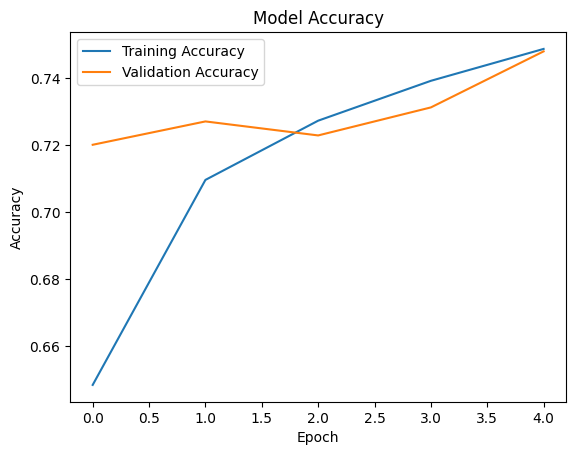

In [ ]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:",accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7521 - loss: 0.7213
Validation Accuracy: 0.7520891427993774


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step


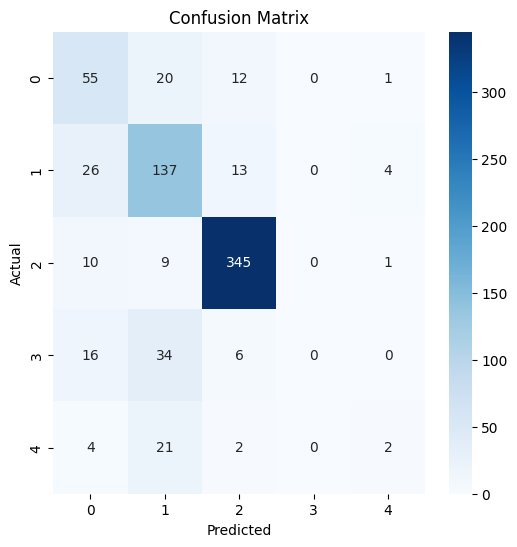

In [ ]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    preds = np.argmax(preds,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.62      0.55        88
           1       0.62      0.76      0.68       180
           2       0.91      0.95      0.93       365
           3       0.00      0.00      0.00        56
           4       0.25      0.07      0.11        29

    accuracy                           0.75       718
   macro avg       0.46      0.48      0.45       718
weighted avg       0.69      0.75      0.72       718



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.save("DR_detection_model.keras")